Here is the Students dataset We will perfom EDA and take out necessary insights


In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\ADMIN\Documents\python\Eda Projects\Students_EDA\AI_Student_Life_india.csv')

In [3]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Education_Level', 'City',
       'AI_Tool_Used', 'Daily_Usage_Hours', 'Purpose', 'Impact_on_Grades',
       'Satisfaction_Level'],
      dtype='object')

In [4]:
df.shape

(400, 10)

In [5]:
df.head(5)

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


In [6]:
df.tail(5)

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
395,96,16,Female,School,Multan,Grammarly,5.0,Learning,Slight Decline,Medium
396,97,25,Female,School,Faisalabad,Gemini,1.9,Writing,No Change,Medium
397,98,17,Female,College,Faisalabad,Gemini,2.9,Writing,No Change,Low
398,99,15,Female,College,Lahore,Notion AI,3.6,Homework,Slight Decline,High
399,100,24,Female,School,Multan,Gemini,2.7,Learning,Improved,High


In [7]:
print('Checking null values: ')
df.isnull().sum()

Checking null values: 


Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          400 non-null    int64  
 1   Age                 400 non-null    int64  
 2   Gender              400 non-null    object 
 3   Education_Level     400 non-null    object 
 4   City                400 non-null    object 
 5   AI_Tool_Used        400 non-null    object 
 6   Daily_Usage_Hours   400 non-null    float64
 7   Purpose             400 non-null    object 
 8   Impact_on_Grades    400 non-null    object 
 9   Satisfaction_Level  400 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 31.4+ KB


From the above details as we can see there are no null values contains so we check for duplicates values

In [40]:
print('Duplicate rows:',df.duplicated().sum())
print('No duplicates values in dataset')

Duplicate rows: 0
No duplicates values in dataset


In [10]:
print('Descriptive statistics: ')
df.describe()

Descriptive statistics: 


,Student_ID,Age,Daily_Usage_Hours
count,400.000000,400.000000,400.000000
mean,125.500000,19.425000,2.933750
std,87.906592,2.991948,1.589939
min,1.000000,15.000000,0.500000
25%,50.750000,17.000000,1.575000
50%,100.500000,19.500000,2.900000
75%,200.250000,22.000000,4.200000
max,300.000000,25.000000,6.000000


In [11]:
print('Desciptive statistics categorical: ')
df.describe(include = 'object')

Desciptive statistics categorical: 


,Gender,Education_Level,City,AI_Tool_Used,Purpose,Impact_on_Grades,Satisfaction_Level
count,400,400,400,400,400,400,400
unique,2,3,15,5,5,3,3
top,Male,College,Delhi,Gemini,Coding,Improved,High
freq,205,146,37,129,104,139,149


From this detail  we get to know about core details of this dataset apart From numerical values

Univariate Analysis


In [43]:
cat_cols = ['Gender','Education_Level','AI_Tool_Used','Purpose','Impact_on_Grades','Satisfaction_Level']
for col in cat_cols:
    a = df[col].value_counts()
    b = (a/len(df) * 100).round(1)
    print(f"\n{col}: ")
    for val , cnt in a.items():
        print(f"{val : <20} {cnt:>4} ({b[val]}%)")


Gender: 
Male                  205 (51.2%)
Female                195 (48.8%)

Education_Level: 
College               146 (36.5%)
School                136 (34.0%)
University            118 (29.5%)

AI_Tool_Used: 
Gemini                129 (32.2%)
ChatGPT               124 (31.0%)
Copilot               108 (27.0%)
Grammarly              24 (6.0%)
Notion AI              15 (3.8%)

Purpose: 
Coding                104 (26.0%)
Writing                96 (24.0%)
Learning               88 (22.0%)
Research               88 (22.0%)
Homework               24 (6.0%)

Impact_on_Grades: 
Improved              139 (34.8%)
No Change             131 (32.8%)
Slight Decline        130 (32.5%)

Satisfaction_Level: 
High                  149 (37.2%)
Low                   142 (35.5%)
Medium                109 (27.3%)


The above data includes gender of male female along with their education,ai tool used ,purpose , impact and their satisfaction of using AI

Categorical Distributions: plot 1 


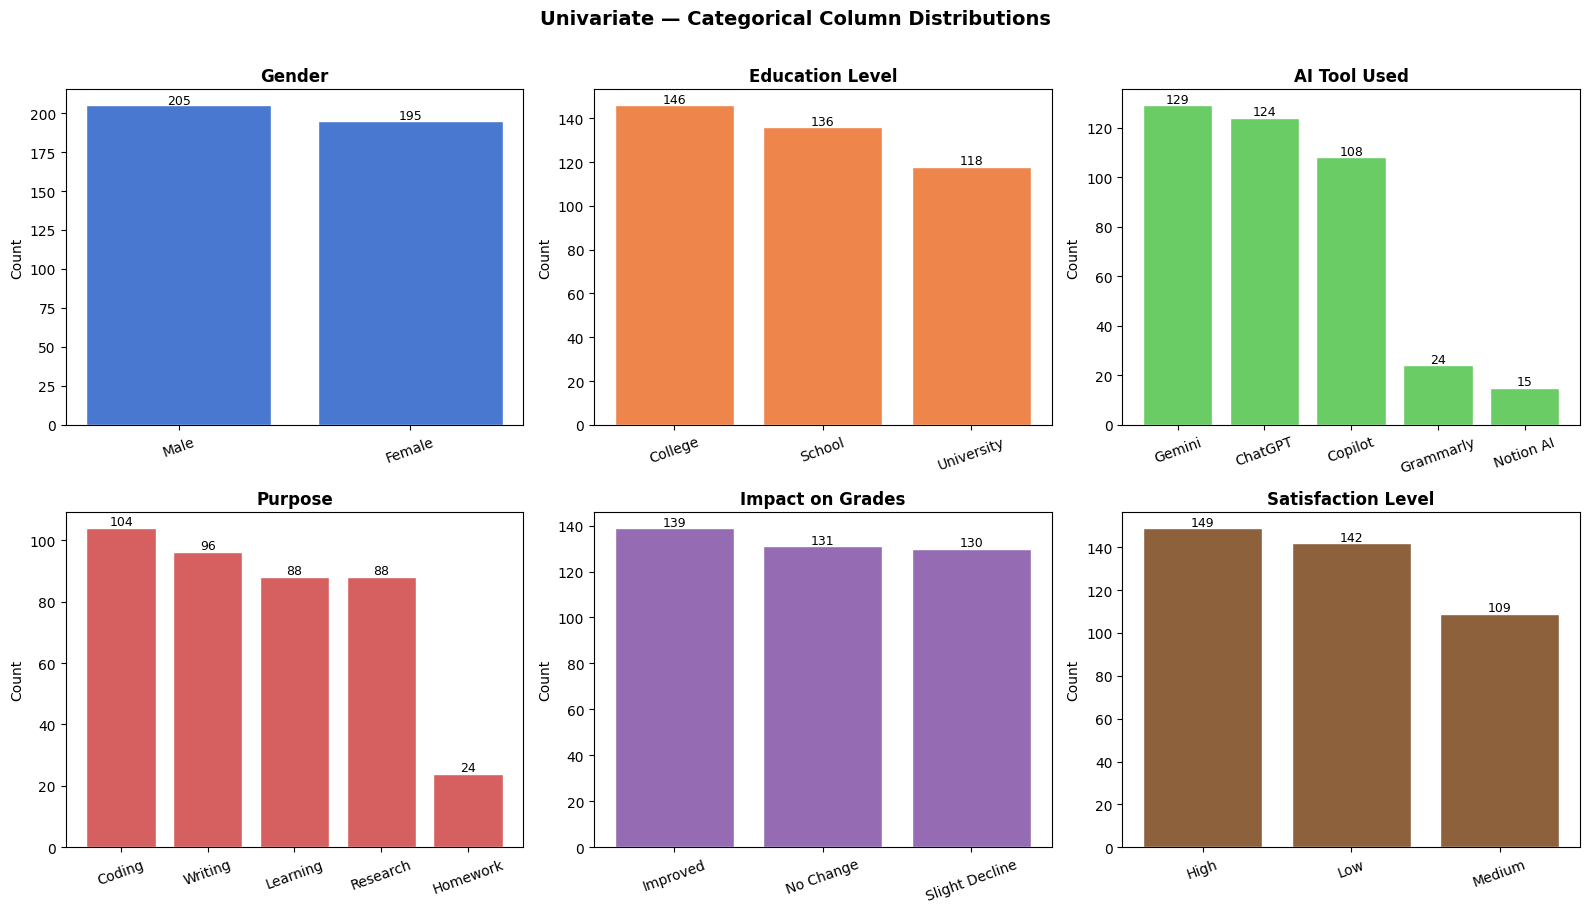

Saved: plot1_univariate_cat.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette("muted", 6)
 
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=colors[i], edgecolor="white")
    axes[i].set_title(col.replace("_", " "), fontweight="bold")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=20)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 1, str(v), ha="center", fontsize=9)
 
plt.suptitle("Univariate — Categorical Column Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot1_univariate_cat.png", bbox_inches="tight")
plt.show()
print("Saved: plot1_univariate_cat.png")

 Above is the bar chart shown of analysis where u can see that purpose of students to use AI is for their Homework and their satisfaction   level they get

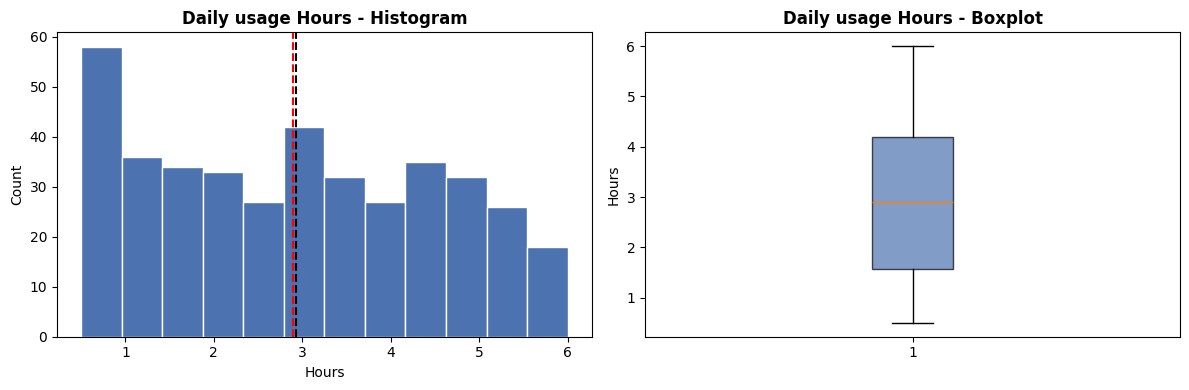

In [14]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['Daily_Usage_Hours'], bins = 12,color = '#4C72B0',edgecolor = 'white')
ax1.set_title("Daily usage Hours - Histogram",fontweight = 'bold')
ax1.set_xlabel('Hours')
ax1.set_ylabel('Count')
ax1.axvline(df['Daily_Usage_Hours'].mean(),color = 'black',linestyle = '--',label = f"Mean : {df['Daily_Usage_Hours'].mean():.2f}")
ax1.axvline(df['Daily_Usage_Hours'].median(),color = 'red',linestyle = '--',label = f"Median : {df['Daily_Usage_Hours'].median():.2f}")

ax2.boxplot(df['Daily_Usage_Hours'],vert = True,patch_artist = True,boxprops = dict(facecolor = '#4C72B0',alpha = 0.7))
ax2.set_title("Daily usage Hours - Boxplot",fontweight = 'bold')
ax2.set_ylabel('Hours')
plt.tight_layout()


                                                    Bivariate Analysis

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          400 non-null    int64  
 1   Age                 400 non-null    int64  
 2   Gender              400 non-null    object 
 3   Education_Level     400 non-null    object 
 4   City                400 non-null    object 
 5   AI_Tool_Used        400 non-null    object 
 6   Daily_Usage_Hours   400 non-null    float64
 7   Purpose             400 non-null    object 
 8   Impact_on_Grades    400 non-null    object 
 9   Satisfaction_Level  400 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 31.4+ KB


In [16]:
grp_cols = ['AI_Tool_Used','Purpose','Impact_on_Grades',
            'Satisfaction_Level','Education_Level','Gender']

print('\n_______ Avg Daily Usage Hours by Group ________\n')

for col in grp_cols:
    grp = df.groupby(col)['Daily_Usage_Hours'].mean().round(2)
    
    print(f"\n--- {col} ---")
    print(grp.to_string())


_______ Avg Daily Usage Hours by Group ________


--- AI_Tool_Used ---
AI_Tool_Used
ChatGPT      3.06
Copilot      2.84
Gemini       2.83
Grammarly    3.41
Notion AI    2.69

--- Purpose ---
Purpose
Coding      3.00
Homework    3.22
Learning    3.14
Research    3.09
Writing     2.46

--- Impact_on_Grades ---
Impact_on_Grades
Improved          3.00
No Change         2.77
Slight Decline    3.02

--- Satisfaction_Level ---
Satisfaction_Level
High      2.97
Low       2.80
Medium    3.06

--- Education_Level ---
Education_Level
College       2.91
School        3.05
University    2.82

--- Gender ---
Gender
Female    2.93
Male      2.93


                                    Average usage by purpose and AI tool

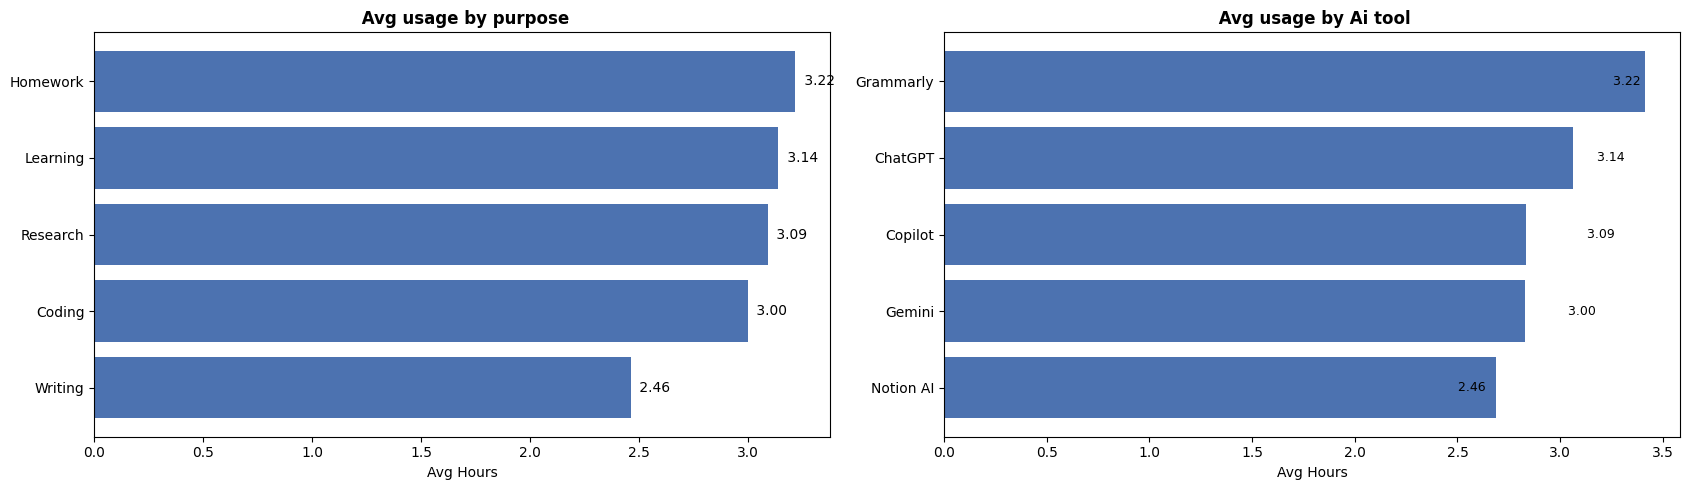

In [17]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
df_1 = df.groupby('Purpose')['Daily_Usage_Hours'].mean().sort_values(ascending = True)
ax1.barh(df_1.index,df_1.values,color = '#4C72B0')
ax1.set_title(' Avg usage by purpose',fontweight = 'bold')
ax1.set_xlabel('Avg Hours')
for i,v in enumerate(df_1.values):
    ax1.text(v + 0.02,i,f"{v: .2f}", va = 'center',fontsize = 10)

df_2 = df.groupby('AI_Tool_Used')['Daily_Usage_Hours'].mean().sort_values(ascending = True)
ax2.barh(df_2.index,df_2.values,color = '#4C72B0')
ax2.set_title(' Avg usage by Ai tool',fontweight = 'bold')
ax2.set_xlabel('Avg Hours')
for i,v in enumerate(df_1.values):
    ax2.text(v + 0.02,i,f"{v: .2f}", va = 'center',fontsize = 9)
plt.tight_layout()
plt.show()


From the above Insights we get to know that Students use Grammerly AI tool mostly for their Homework instead of chatgpt, or any other

Plot 5 = AI tool vs impact on grades

In [18]:
df_3 = pd.crosstab(df['AI_Tool_Used'],df['Impact_on_Grades'])
print('--------------AI tool VS Impact on Grades :------\n',df_3)

--------------AI tool VS Impact on Grades :------
 Impact_on_Grades  Improved  No Change  Slight Decline
AI_Tool_Used                                         
ChatGPT                 47         43              34
Copilot                 33         37              38
Gemini                  46         40              43
Grammarly                6          7              11
Notion AI                7          4               4


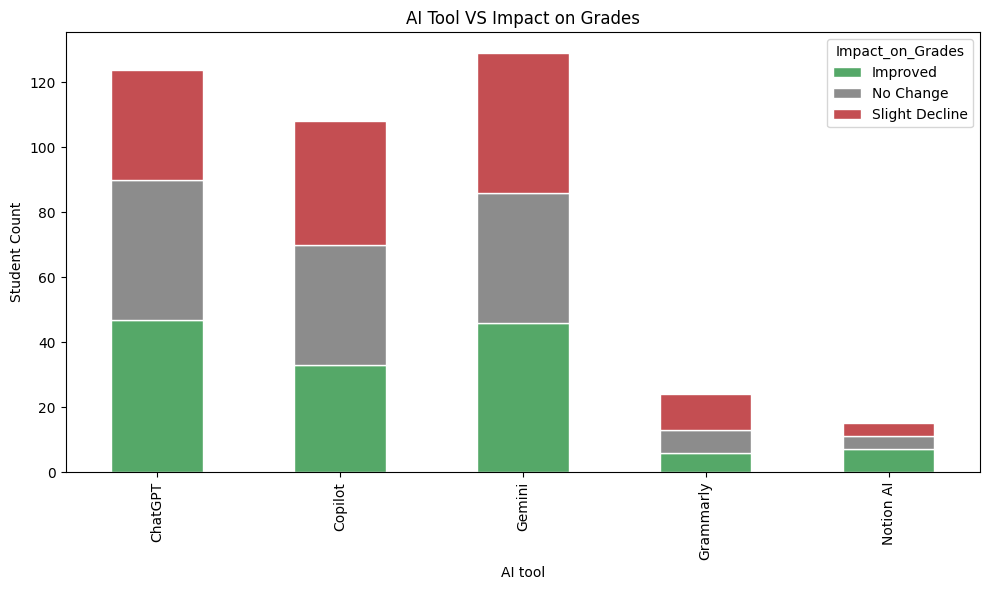

In [19]:
df_3.plot(kind = 'bar',stacked = True,figsize = (10,6),color = ['#55A868','#8C8C8C','#C44E52'],edgecolor = 'white')
plt.title('AI Tool VS Impact on Grades')
plt.xlabel('AI tool')
plt.ylabel('Student Count')
plt.tight_layout()
plt.show()

Plot 6 : Education VS Satisfaction level

In [20]:
df_4 = pd.crosstab(df['Education_Level'],df['Satisfaction_Level'])
print('-------------Education level vs  Satisfaction level--------:\n',df_4)

-------------Education level vs  Satisfaction level--------:
 Satisfaction_Level  High  Low  Medium
Education_Level                      
College               45   63      38
School                55   44      37
University            49   35      34


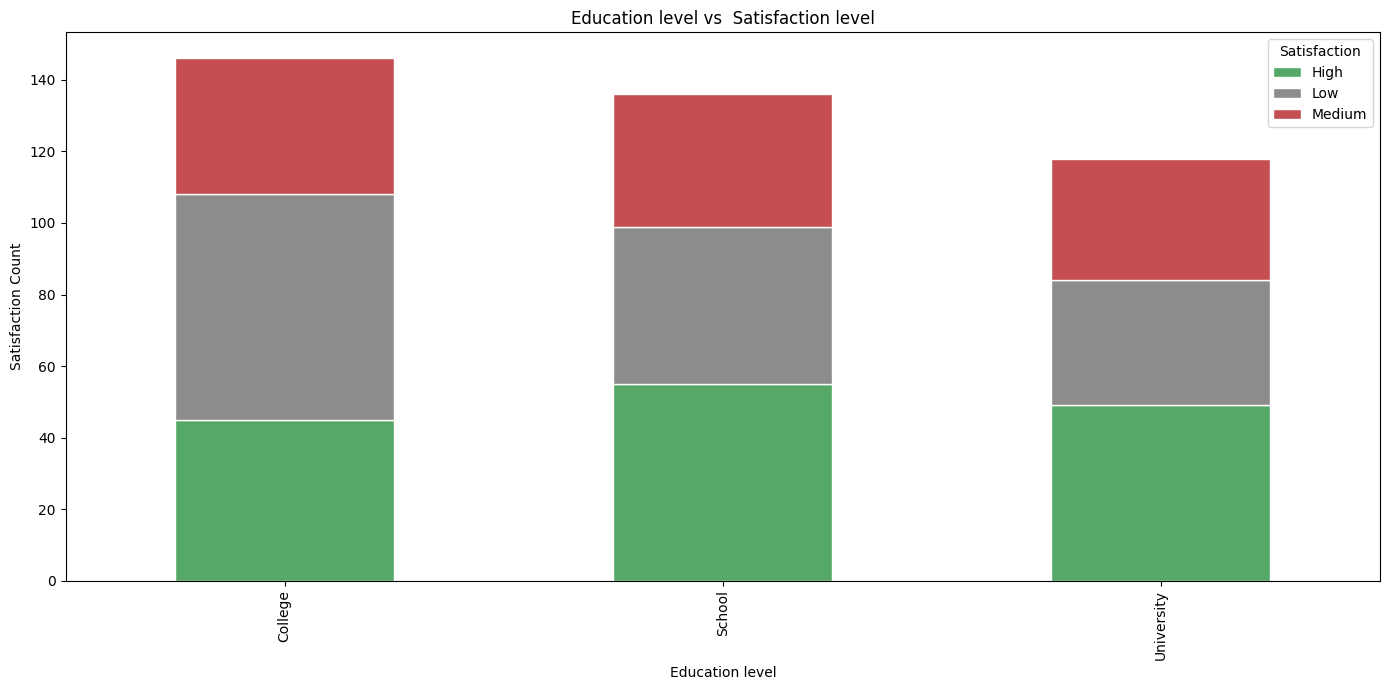

In [21]:
df_4.plot(kind = 'bar',stacked = True,figsize = (14,7),color = ['#55A868','#8C8C8C','#C44E52'],edgecolor = 'white')
plt.title('Education level vs  Satisfaction level')
plt.xlabel('Education level')
plt.ylabel('Satisfaction Count')
plt.legend(title = 'Satisfaction')
plt.tight_layout()
plt.show()

Plot 7: Usage Hours by impact on grades

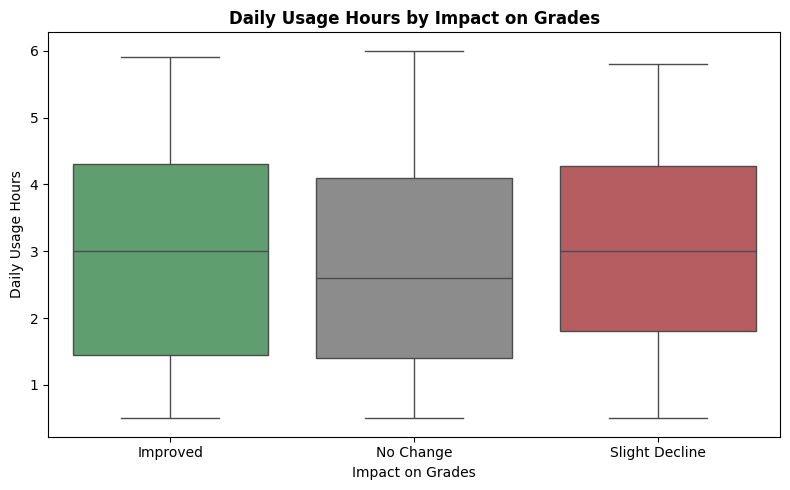

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ["Improved", "No Change", "Slight Decline"]
palette = {"Improved": "#55A868", "No Change": "#8C8C8C", "Slight Decline": "#C44E52"}
sns.boxplot(data=df, x="Impact_on_Grades", y="Daily_Usage_Hours",
            order=order, palette=palette, ax=ax,legend = False,hue ='Impact_on_Grades')
ax.set_title("Daily Usage Hours by Impact on Grades", fontweight="bold")
ax.set_xlabel("Impact on Grades")
ax.set_ylabel("Daily Usage Hours")
plt.tight_layout()
plt.show()

Plot 8: Gender Breakdown accross key metrices

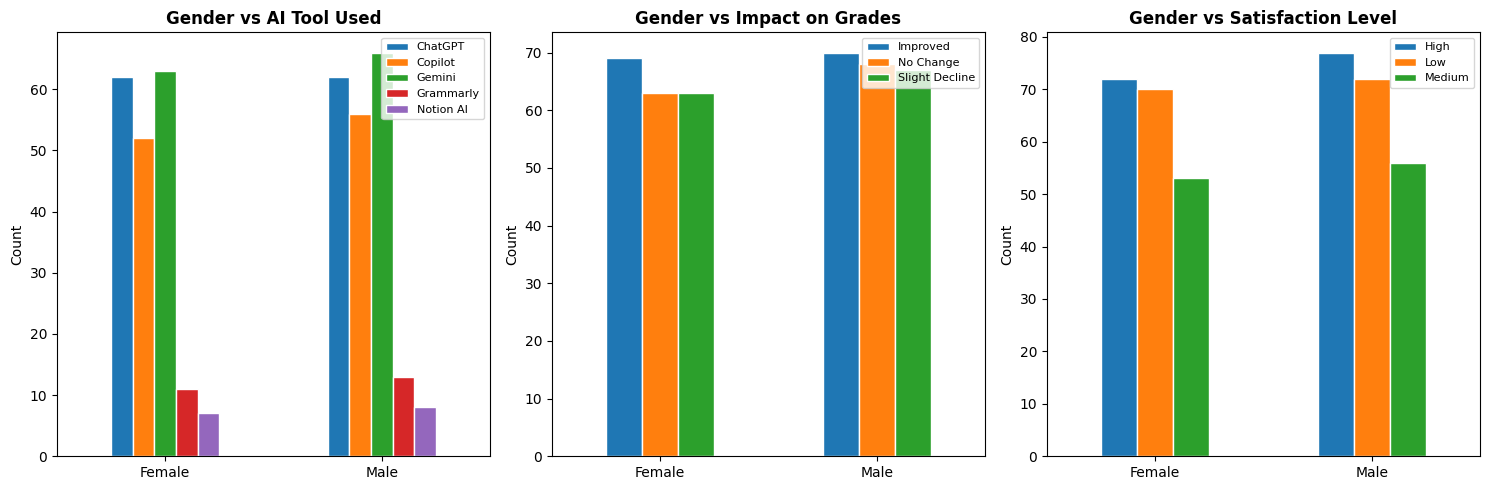

In [23]:
fig,axes = plt.subplots(1,3,figsize = (15,5))
for ax, col in zip(axes,['AI_Tool_Used','Impact_on_Grades','Satisfaction_Level']):
    ct = pd.crosstab(df['Gender'],df[col])
    ct.plot(kind = 'bar',ax = ax,edgecolor = 'white')
    ax.set_title(f"Gender vs {col.replace('_',' ')}",fontweight = 'bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis = 'x',rotation = 0)
    ax.legend(fontsize = 8,loc = 'upper right')
plt.tight_layout()
plt.show()

Multivariate analysis


In [24]:
pivot = df.pivot_table(values = 'Daily_Usage_Hours',index = 'Purpose',columns= 'Impact_on_Grades',aggfunc='mean').round(2)
print(f"Average usage hours \n{pivot}")

Average usage hours 
Impact_on_Grades  Improved  No Change  Slight Decline
Purpose                                              
Coding                3.17       2.82            2.99
Homework              3.94       2.45            3.44
Learning              3.11       2.84            3.42
Research              2.95       3.22            3.14
Writing               2.49       2.43            2.47


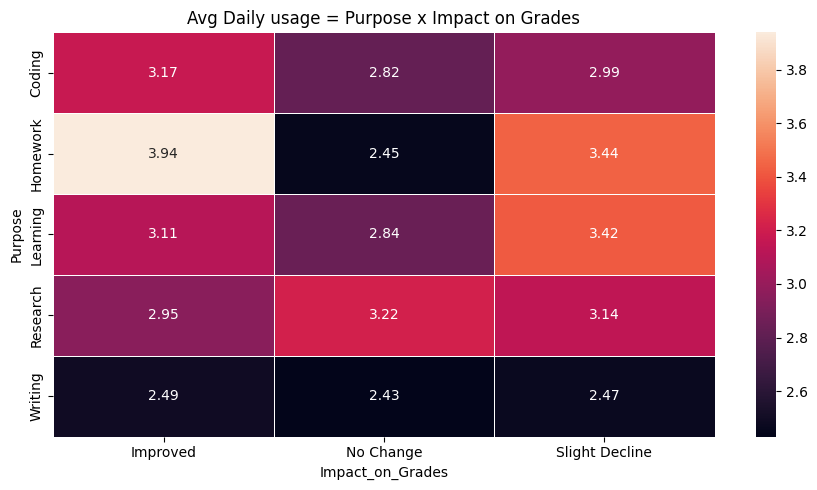

In [25]:
fig, ax = plt.subplots(figsize = (9,5))
sns.heatmap(data= pivot,annot = True,fmt = '.2f',linewidths= 0.5,ax = ax)
ax.set_title('Avg Daily usage = Purpose x Impact on Grades')
plt.tight_layout()
plt.show()

In [26]:
pivot_1 = df.pivot_table(values = 'Student_ID',index = 'Education_Level',columns= 'AI_Tool_Used',aggfunc='count').fillna(0).astype(int)
print('\n------Student Count(Education x AI Tool)-----------\n',pivot_1)


------Student Count(Education x AI Tool)-----------
 AI_Tool_Used     ChatGPT  Copilot  Gemini  Grammarly  Notion AI
Education_Level                                                
College               46       34      54          6          6
School                45       38      36         11          6
University            33       36      39          7          3


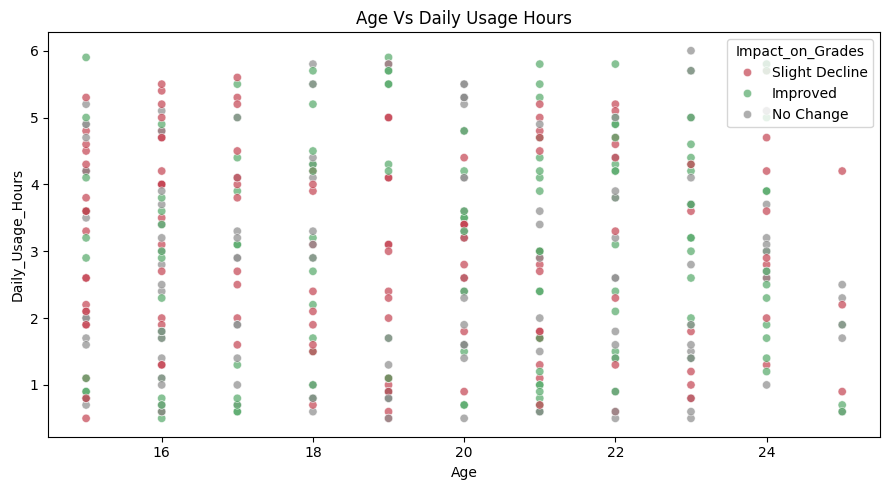

In [27]:
fig,ax = plt.subplots(figsize =(9,5))
sns.scatterplot(data = df,x = 'Age',y = 'Daily_Usage_Hours',hue = 'Impact_on_Grades',
                palette= {'Improved': '#55A868',
                         'No Change': '#8C8C8C',
                         'Slight Decline': '#C44352'},
                alpha = 0.7,ax = ax)
ax.set_title('Age Vs Daily Usage Hours')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

Statistical Testing

In [28]:
from scipy.stats import chi2_contingency
print('----------Statistical Testing (Chi-square Test)------------\n')
pairs = [('AI_Tool_Used','Impact_on_Grades'),('Education_Level','Satisfaction_Level'),('Purpose','Impact_on_Grades'),
         ('Gender','Satisfaction_Level'),
        ]
for col1,col2 in pairs:
    a = pd.crosstab(df[col1],df[col2])
    chi2,p,dof,expected = chi2_contingency(a)
    result = 'Significant ' if p < 0.05 else 'Not Significant'
    print(f"\n{col1} vs {col2}")
    print(f"Chi2 = {chi2:.3f} | p = {p:.4f} | df = {dof} -> {result}")

----------Statistical Testing (Chi-square Test)------------


AI_Tool_Used vs Impact_on_Grades
Chi2 = 5.523 | p = 0.7005 | df = 8 -> Not Significant

Education_Level vs Satisfaction_Level
Chi2 = 6.676 | p = 0.1540 | df = 4 -> Not Significant

Purpose vs Impact_on_Grades
Chi2 = 3.385 | p = 0.9080 | df = 8 -> Not Significant

Gender vs Satisfaction_Level
Chi2 = 0.029 | p = 0.9858 | df = 2 -> Not Significant


In [36]:
print('----Final Summary --------\n')
summary = {
    'Total Students':len(df),
    '\nAvg Daily Usage(hrs)':round(df['Daily_Usage_Hours'].mean(),2),
    '\nMedian Daily Usage(hrs)':round(df['Daily_Usage_Hours'].median(),2),
    '\nStd Daily Usage(hrs)':round(df['Daily_Usage_Hours'].std(),2),
    '\nMost Used Tool':df['AI_Tool_Used'].mode(),
    '\nMost Common Purpose':df['Purpose'].mode(),
    '\nMost Common Grade Impact':df['Impact_on_Grades'].mode(),
    '\nMost Common Satisfaction':df['Satisfaction_Level'].mode(),
    '\n%Improved Grades':f"{(df['Impact_on_Grades'] == 'Improved').mean() * 100:.1f}%",
    '\n%High satisfaction':f"{(df['Satisfaction_Level'] == 'High').mean() * 100:.1f}%",
}

for k,v in summary.items():
    print(f" {k:<30} {v}")
print("\n EDA complete. All plots are Gain after analysis")

----Final Summary --------

 Total Students                 400
 
Avg Daily Usage(hrs)          2.93
 
Median Daily Usage(hrs)       2.9
 
Std Daily Usage(hrs)          1.59
 
Most Used Tool                0    Gemini
Name: AI_Tool_Used, dtype: object
 
Most Common Purpose           0    Coding
Name: Purpose, dtype: object
 
Most Common Grade Impact      0    Improved
Name: Impact_on_Grades, dtype: object
 
Most Common Satisfaction      0    High
Name: Satisfaction_Level, dtype: object
 
%Improved Grades              34.8%
 
%High satisfaction            37.2%

 EDA complete. All plots are Gain after analysis
